In [87]:
import pandas as pd 
import numpy as np 
from pathlib import Path 

In [88]:
citation = pd.read_csv("Parking_Citations_20260404.csv", nrows=500_000)
print(f"Loaded: {len(citation):,} rows")
citation.head()

Loaded: 500,000 rows


,issue_date,issue_time,make,body_style,violation_description,fine_amount,loc_lat,loc_long
0,2025 Apr 26 12:00:00 AM,904,FORD,PA,DOUBLE PARKING,68,34.038267,-118.299593
1,2025 Apr 26 12:00:00 AM,830,CHEV,PA,FIRE HYDRANT,68,34.163370,-118.431059
2,2025 Apr 26 12:00:00 AM,825,TOYT,PA,METER EXP.,63,34.052868,-118.260923
3,2025 Apr 26 12:00:00 AM,935,CHEV,PU,STANDNG IN ALLEY,68,33.788801,-118.304095
4,2025 Apr 26 12:00:00 AM,"1,255",NISS,PA,EXCEED 72HRS-ST,68,34.208873,-118.592801


In [89]:
# Parse issue_date for month and day of week
citation['issue_date'] = pd.to_datetime(citation['issue_date'], format='%Y %b %d %I:%M:%S %p')
citation['month'] = citation['issue_date'].dt.month_name()
citation['day_of_week'] = citation['issue_date'].dt.day_name()

# Parse issue_time (HHMM integer, may have commas or NaNs) into a readable time string
time_str = citation['issue_time'].astype(str).str.replace(',', '', regex=False).str.zfill(4)
time_str = time_str.where(time_str.str.match(r'^\d{4}$'), other=np.nan)
citation['time'] = pd.to_datetime(time_str, format='%H%M', errors='coerce').dt.strftime('%I:%M %p')

citation[['issue_date', 'month', 'day_of_week', 'time']].head()

,issue_date,month,day_of_week,time
0,2025-04-26,April,Saturday,09:04 AM
1,2025-04-26,April,Saturday,08:30 AM
2,2025-04-26,April,Saturday,08:25 AM
3,2025-04-26,April,Saturday,09:35 AM
4,2025-04-26,April,Saturday,12:55 PM


In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

# Extract hour from issue_time (already cleaned — strip commas, cast to int)
citation['hour'] = citation['issue_time'].str.replace(',', '', regex=False).astype(float) // 100

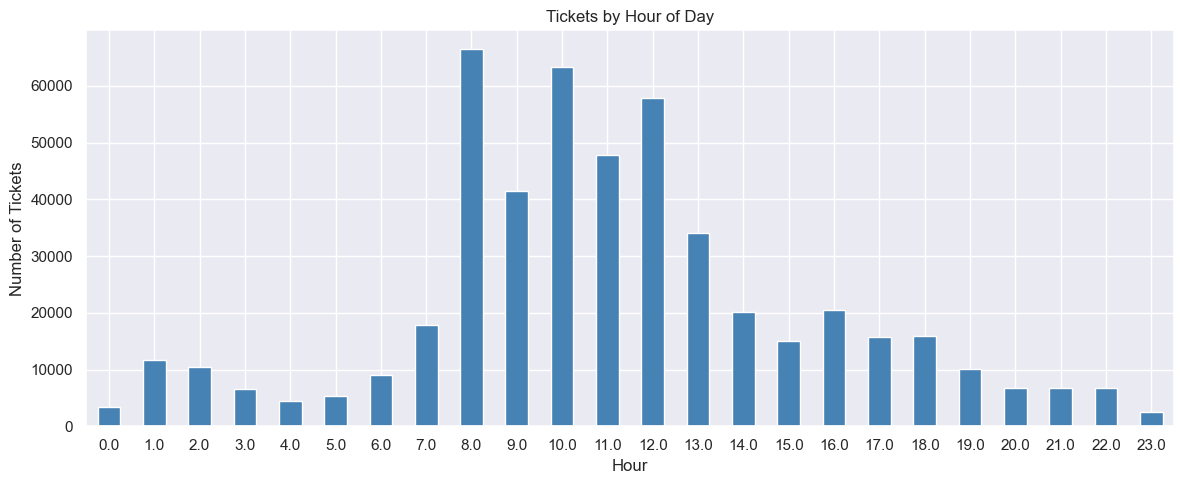

In [91]:
# Peak Ticket Times by Hour
plt.figure(figsize=(12, 5))
citation.groupby('hour').size().plot(kind='bar', color='steelblue')
plt.title('Tickets by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\josep\AppData\Local\Temp\ipykernel_14084\4010098763.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_violations.values, y=top_violations.index, palette='flare')


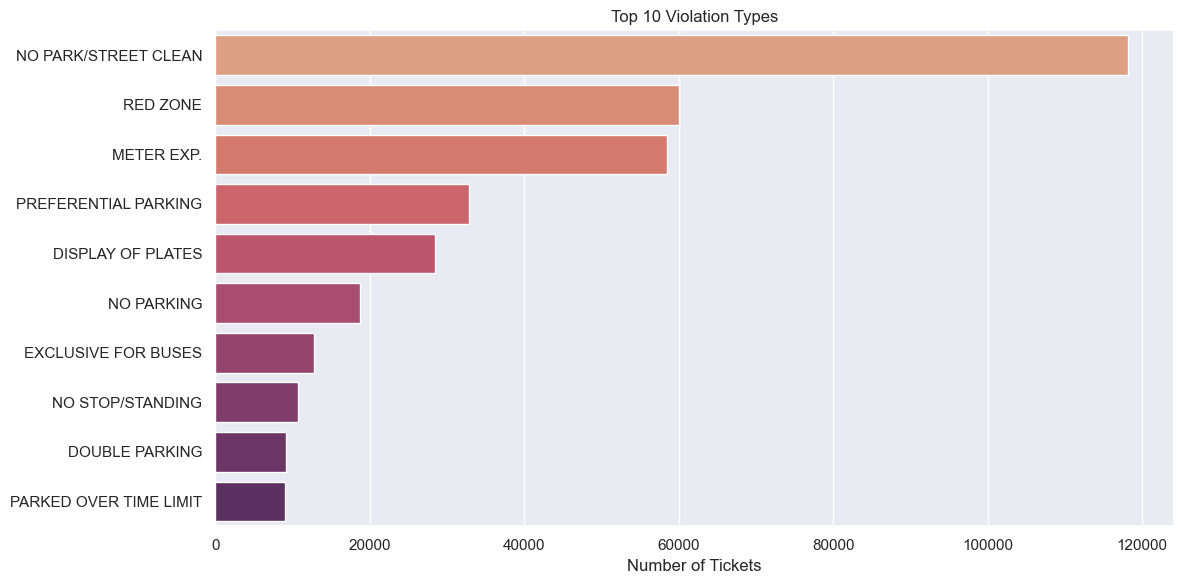

In [92]:
# Violation Breakdown — Top 10
top_violations = citation['violation_description'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_violations.values, y=top_violations.index, palette='flare')
plt.title('Top 10 Violation Types')
plt.xlabel('Number of Tickets')
plt.ylabel('')
plt.tight_layout()
plt.show()

Total Revenue:   $40,357,079.00
Average Fine:    $80.75


C:\Users\josep\AppData\Local\Temp\ipykernel_14084\1709037353.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_violation.values, y=revenue_by_violation.index, palette='rocket')


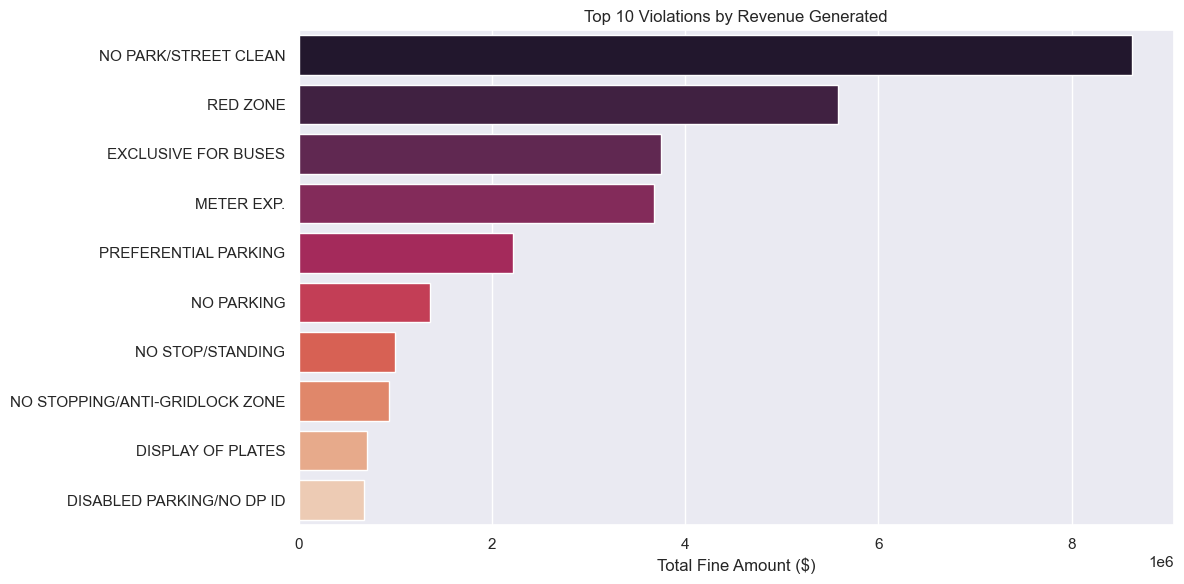

In [93]:
# Revenue Analysis
citation['fine_amount'] = pd.to_numeric(citation['fine_amount'], errors='coerce')

total_revenue = citation['fine_amount'].sum()
avg_fine = citation['fine_amount'].mean()
print(f"Total Revenue:   ${total_revenue:,.2f}")
print(f"Average Fine:    ${avg_fine:.2f}")

# Revenue by violation type
revenue_by_violation = (
    citation.groupby('violation_description')['fine_amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=revenue_by_violation.values, y=revenue_by_violation.index, palette='rocket')
plt.title('Top 10 Violations by Revenue Generated')
plt.xlabel('Total Fine Amount ($)')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [94]:
# Risk Score per Location (grid-based)
# Drop rows missing coordinates
geo = citation.dropna(subset=['loc_lat', 'loc_long']).copy()

# Round coords to ~0.5km grid
geo['lat_grid'] = geo['loc_lat'].round(2)
geo['lon_grid'] = geo['loc_long'].round(2)

grid = geo.groupby(['lat_grid', 'lon_grid']).agg(
    ticket_density=('fine_amount', 'count'),
    avg_fine=('fine_amount', 'mean'),
    peak_hour=('hour', lambda x: x.mode()[0] if not x.mode().empty else np.nan)
).reset_index()

# Normalize each component 0–1 then combine into risk score
for col in ['ticket_density', 'avg_fine']:
    grid[col + '_norm'] = (grid[col] - grid[col].min()) / (grid[col].max() - grid[col].min())

grid['risk_score'] = (grid['ticket_density_norm'] * 0.6 + grid['avg_fine_norm'] * 0.4).round(3)

print(f"Grid cells: {len(grid)}")
grid.sort_values('risk_score', ascending=False).head(10)

Grid cells: 1644


,lat_grid,lon_grid,ticket_density,avg_fine,peak_hour,ticket_density_norm,avg_fine_norm,risk_score
615,34.05,-118.25,12190,120.909024,11.0,1.000000,0.241818,0.697
574,34.04,-118.25,10909,86.886424,12.0,0.894905,0.173773,0.606
614,34.05,-118.26,7909,105.922114,12.0,0.648782,0.211844,0.474
649,34.06,-118.30,7215,136.232294,8.0,0.591845,0.272465,0.464
573,34.04,-118.26,7041,80.017185,11.0,0.577570,0.160034,0.411
650,34.06,-118.29,5937,136.057605,16.0,0.486996,0.272115,0.401
442,34.00,-117.42,1,500.000000,20.0,0.000000,1.000000,0.400
126,33.80,-118.21,1,500.000000,6.0,0.000000,1.000000,0.400
4,14.64,120.97,1,500.000000,17.0,0.000000,1.000000,0.400
163,33.84,-117.93,3,500.000000,9.0,0.000164,1.000000,0.400


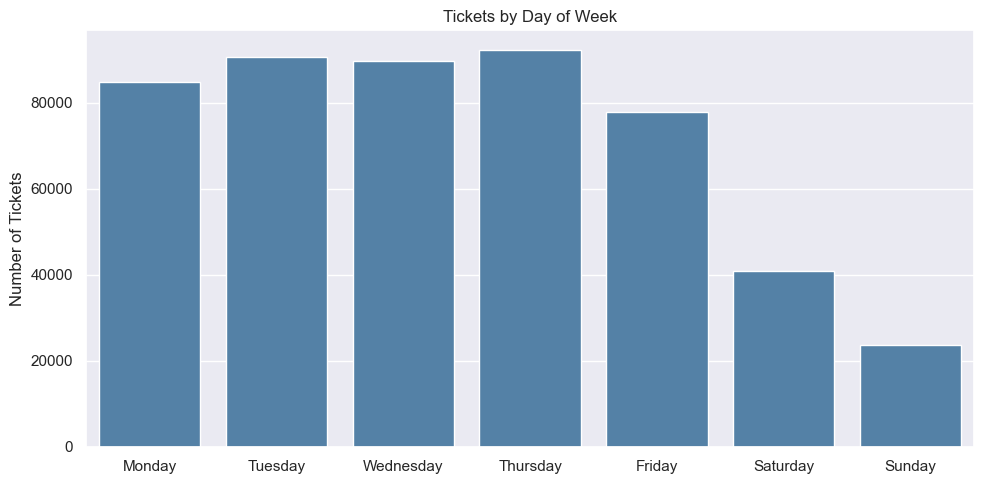

In [95]:
# Tickets by Day of Week (ordered Mon-Sun)
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_counts = citation["day_of_week"].value_counts().reindex(dow_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=dow_counts.index, y=dow_counts.values, color="steelblue")
plt.title("Tickets by Day of Week")
plt.xlabel("")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

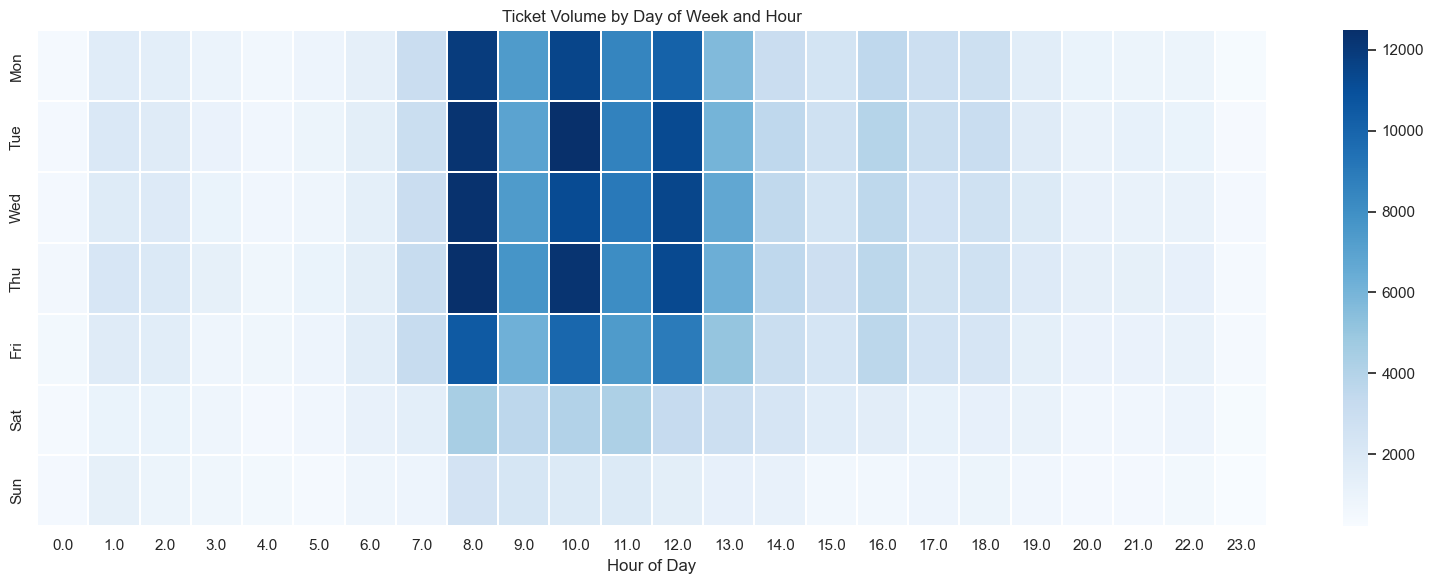

In [96]:
# Day of Week x Hour Heatmap -- shows peak risk windows
citation["dow_num"] = citation["issue_date"].dt.dayofweek
heatmap_data = citation.groupby(["dow_num", "hour"]).size().reset_index(name="count")
heatmap_pivot = heatmap_data.pivot(index="dow_num", columns="hour", values="count")
heatmap_pivot.index = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_pivot, cmap="Blues", fmt=".0f", linewidths=0.3)
plt.title("Ticket Volume by Day of Week and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("")
plt.tight_layout()
plt.show()

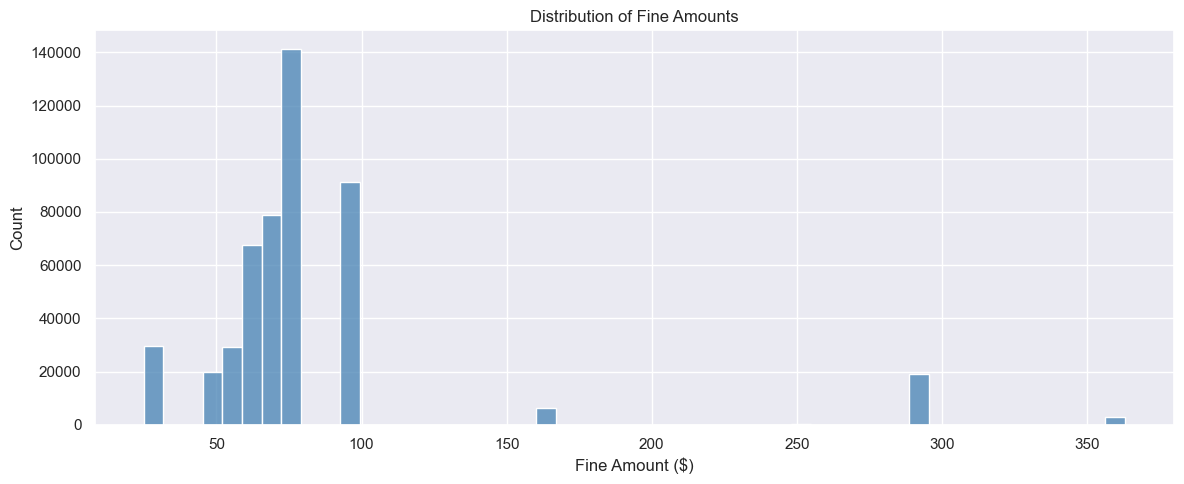

In [98]:
# Distribution of Fine Amounts
fine_data = citation[(citation["fine_amount"] > 0) & (citation["fine_amount"] < 500)]["fine_amount"]

plt.figure(figsize=(12, 5))
sns.histplot(fine_data, bins=50, color="steelblue")
plt.title("Distribution of Fine Amounts")
plt.xlabel("Fine Amount ($)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

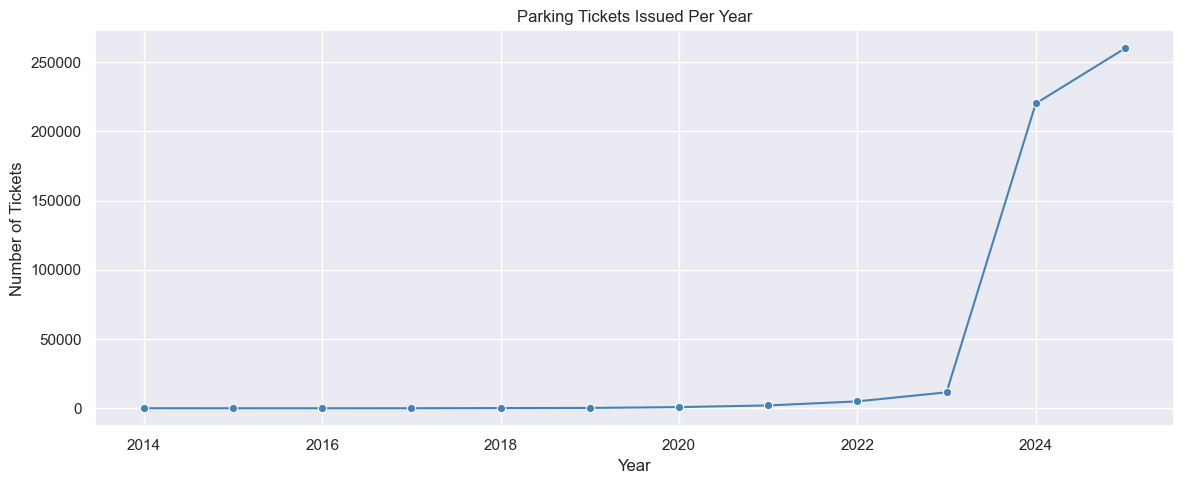

In [99]:
# Tickets Per Year (trend)
citation["year"] = citation["issue_date"].dt.year
yearly = citation[(citation["year"] >= 2010) & (citation["year"] <= 2025)].groupby("year").size()

plt.figure(figsize=(12, 5))
sns.lineplot(x=yearly.index, y=yearly.values, marker="o", color="steelblue")
plt.title("Parking Tickets Issued Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

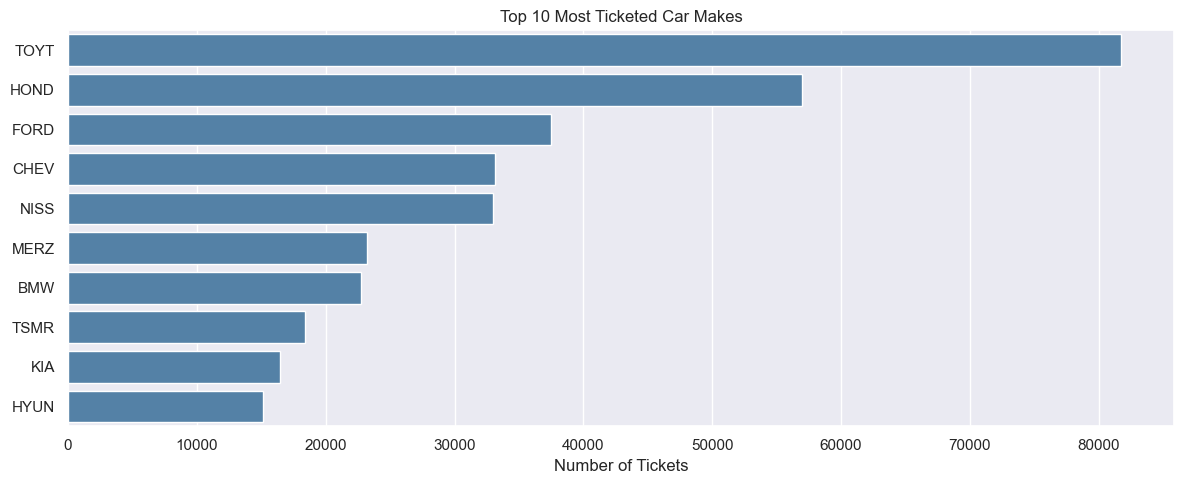

In [100]:
# Top 10 Most Ticketed Car Makes
top_makes = citation["make"].value_counts().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_makes.values, y=top_makes.index, color="steelblue")
plt.title("Top 10 Most Ticketed Car Makes")
plt.xlabel("Number of Tickets")
plt.ylabel("")
plt.tight_layout()
plt.show()

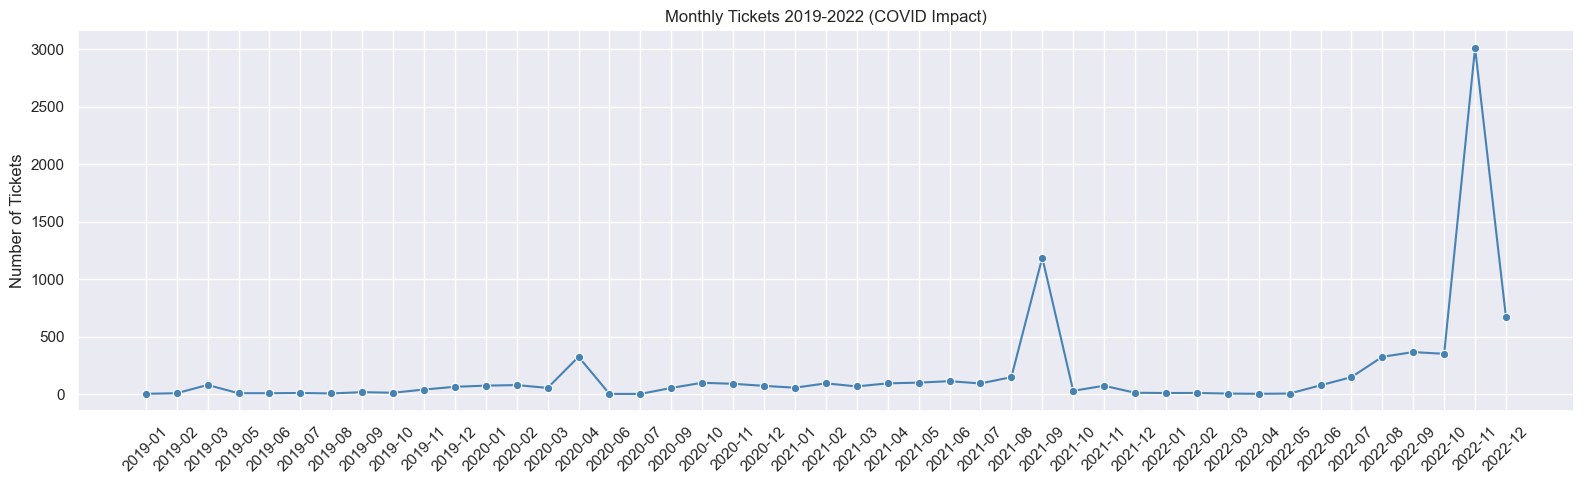

In [101]:
# Monthly Ticket Volume 2019-2022 (COVID impact story)
monthly_df = citation.copy()
monthly_df["year"] = monthly_df["issue_date"].dt.year
monthly_df["month_num"] = monthly_df["issue_date"].dt.month
monthly_df = monthly_df[monthly_df["year"].between(2019, 2022)]
monthly_df["year_month"] = (monthly_df["year"].astype(str) + "-" +
                            monthly_df["month_num"].astype(str).str.zfill(2))
monthly_counts = monthly_df.groupby("year_month").size().reset_index(name="count").sort_values("year_month")

plt.figure(figsize=(16, 5))
sns.lineplot(data=monthly_counts, x="year_month", y="count", marker="o", color="steelblue")
plt.title("Monthly Tickets 2019-2022 (COVID Impact)")
plt.xlabel("")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [102]:
# Interactive Geographic Heatmap (requires: pip install folium)
import folium
from folium.plugins import HeatMap

geo_sample = citation[
    citation["loc_lat"].notna() &
    citation["loc_long"].notna() &
    (citation["loc_lat"] != 0) &
    (citation["loc_long"] != 0)
].sample(n=min(50000, len(citation)), random_state=42)[["loc_lat", "loc_long"]]

m = folium.Map(location=[34.0522, -118.2437], zoom_start=11)
HeatMap(geo_sample.values.tolist(), radius=8, blur=10, max_zoom=13).add_to(m)
m.save("parking_heatmap.html")
print("Saved to parking_heatmap.html -- open in browser")
m

Saved to parking_heatmap.html -- open in browser


# SpotWise ML System

## Problem 1 — Ticket Risk Score
Given a location + time, how likely is a ticket?
- Built as a **lookup table**: group historical citations by (grid cell, hour window, day of week) and normalize to 0-100%
- No ML needed — pure density estimation

## Problem 2 — Violation Type Prediction
Given a location + time, what kind of ticket will it be?
- **Models:** Logistic Regression (baseline) → Random Forest → XGBoost (best)
- **Features:** hour, day of week, is_weekend, month, lat/lon grid
- **Output:** top 3 most likely violations with probabilities

## Full Pipeline
```
Address → geocode → (lat, lon) → grid cell
    |-- Risk score lookup  → "72% risk"
    |-- XGBoost classifier → "Street Cleaning 50%, No Parking 30%, ..."
```

In [103]:
# Feature Engineering
from sklearn.preprocessing import LabelEncoder

df = citation.copy()

# Time features
df['hour']        = df['issue_time'].str.replace(',', '', regex=False).astype(float) // 100
df['dow']         = df['issue_date'].dt.dayofweek          # 0=Mon … 6=Sun
df['is_weekend']  = (df['dow'] >= 5).astype(int)
df['month_num']   = df['issue_date'].dt.month

# Location features (~0.5 km grid)
df['lat_grid'] = df['loc_lat'].round(2)
df['lon_grid'] = df['loc_long'].round(2)

# Vehicle features — keep top 20 makes, collapse rest to "OTHER"
top_makes = df['make'].value_counts().nlargest(20).index
df['make_clean'] = df['make'].where(df['make'].isin(top_makes), other='OTHER')

# Encode categoricals
le_make  = LabelEncoder()
le_body  = LabelEncoder()
df['make_enc'] = le_make.fit_transform(df['make_clean'].fillna('OTHER'))
df['body_enc'] = le_body.fit_transform(df['body_style'].fillna('OTHER'))

# Target — keep top 10 violations, collapse rest to "OTHER"
top_violations = df['violation_description'].value_counts().nlargest(10).index
df['target'] = df['violation_description'].where(df['violation_description'].isin(top_violations), other='OTHER')

le_target = LabelEncoder()
df['target_enc'] = le_target.fit_transform(df['target'])

print("Classes:", le_target.classes_)
print("Feature sample:")
df[['hour','dow','is_weekend','month_num','lat_grid','lon_grid','make_enc','body_enc','target']].head()

Classes: ['DISPLAY OF PLATES' 'DOUBLE PARKING' 'EXCLUSIVE FOR BUSES' 'METER EXP.'
 'NO PARK/STREET CLEAN' 'NO PARKING' 'NO STOP/STANDING' 'OTHER'
 'PARKED OVER TIME LIMIT' 'PREFERENTIAL PARKING' 'RED ZONE']
Feature sample:


,hour,dow,is_weekend,month_num,lat_grid,lon_grid,make_enc,body_enc,target
0,9.0,5,1,4,34.04,-118.30,4,81,DOUBLE PARKING
1,8.0,5,1,4,34.16,-118.43,2,81,OTHER
2,8.0,5,1,4,34.05,-118.26,18,81,METER EXP.
3,9.0,5,1,4,33.79,-118.30,2,86,OTHER
4,12.0,5,1,4,34.21,-118.59,14,81,OTHER


In [104]:
# Problem 1: Risk Score Lookup Table
# Group by location grid + 3-hour time window + day of week → normalize to 0-100%

risk_df = df.dropna(subset=["lat_grid", "lon_grid", "hour", "dow"]).copy()
risk_df["hour_bucket"] = (risk_df["hour"] // 3 * 3).astype(int)  # 0,3,6,9,12,15,18,21

risk_table = (
    risk_df.groupby(["lat_grid", "lon_grid", "hour_bucket", "dow"])
    .size()
    .reset_index(name="ticket_count")
)

max_count = risk_table["ticket_count"].max()
risk_table["risk_score"] = (risk_table["ticket_count"] / max_count * 100).round(1)

print(f"Risk table: {len(risk_table):,} grid cells")
print(f"Risk range: {risk_table["risk_score"].min()}% – {risk_table["risk_score"].max()}%")
risk_table.sort_values("risk_score", ascending=False).head(10)

Risk table: 32,476 grid cells
Risk range: 0.1% – 100.0%


,lat_grid,lon_grid,hour_bucket,dow,ticket_count,risk_score
13506,34.05,-118.25,9,1,837,100.0
13514,34.05,-118.25,12,2,806,96.3
11966,34.04,-118.25,12,2,751,89.7
13507,34.05,-118.25,9,2,749,89.5
13513,34.05,-118.25,12,1,719,85.9
13505,34.05,-118.25,9,0,709,84.7
13512,34.05,-118.25,12,0,700,83.6
11968,34.04,-118.25,12,4,697,83.3
11957,34.04,-118.25,9,0,682,81.5
11960,34.04,-118.25,9,3,664,79.3


In [105]:
# Train / Test Split
from sklearn.model_selection import train_test_split

FEATURES = ['hour', 'dow', 'is_weekend', 'month_num', 'lat_grid', 'lon_grid', 'make_enc', 'body_enc']

ml = df[FEATURES + ['target_enc']].dropna()
X = ml[FEATURES]
y = ml['target_enc']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Train: 399,993  |  Test: 99,999


In [ ]:
# Model Comparison -- Logistic Regression, Random Forest, XGBoost
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost":        XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                                    eval_metric="mlogloss", random_state=42, n_jobs=-1),
}

results = {}
n_classes = len(le_target.classes_)
y_bin = label_binarize(y_test, classes=range(n_classes))

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average="weighted")
    auc = roc_auc_score(y_bin, proba, multi_class="ovr", average="weighted")
    results[name] = {"Accuracy": acc, "F1 (weighted)": f1, "ROC-AUC": auc}
    print(f"{name:25s}  acc={acc:.3f}  f1={f1:.3f}  auc={auc:.3f}")

results_df = pd.DataFrame(results).T
results_df

c:\Users\josep\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression        acc=0.337  f1=0.242  auc=0.624
Random Forest              acc=0.615  f1=0.603  auc=0.869


c:\Users\josep\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:56:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost                    acc=0.587  f1=0.548  auc=0.871


,Accuracy,F1 (weighted),ROC-AUC
Logistic Regression,0.337003,0.241865,0.624444
Random Forest,0.615416,0.603350,0.869371
XGBoost,0.587076,0.548011,0.870581


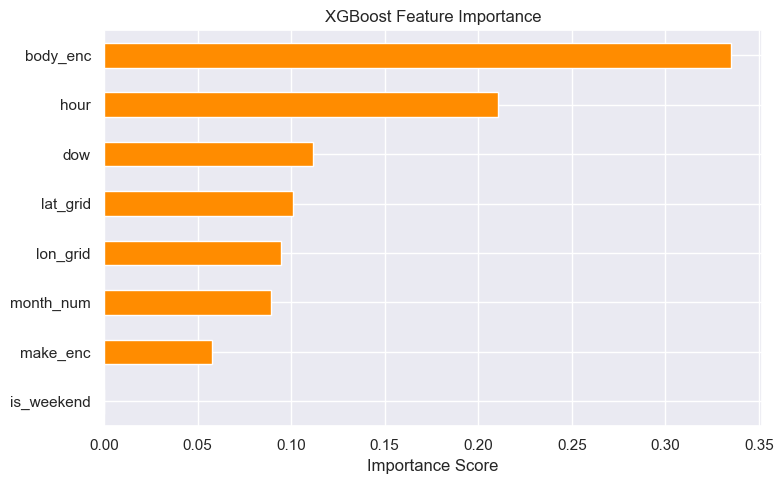

In [ ]:
# XGBoost Feature Importance
xgb_model = models['XGBoost']

importance = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values()

plt.figure(figsize=(8, 5))
importance.plot(kind='barh', color='darkorange')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [111]:
# XGBoost Hyperparameter Tuning
# Uses a smaller subsample + sequential jobs to avoid memory errors
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth":     [4, 6],
    "learning_rate": [0.1, 0.2],
    "n_estimators":  [100, 200],
}

# Subsample training data to keep memory manageable
tune_size = min(50_000, len(X_train))
X_tune = X_train.sample(tune_size, random_state=42)
y_tune = y_train.loc[X_tune.index]

xgb_tune = XGBClassifier(eval_metric="mlogloss", random_state=42, n_jobs=1)
gs = GridSearchCV(xgb_tune, param_grid, cv=3, scoring="f1_weighted", verbose=1, n_jobs=1)
gs.fit(X_tune, y_tune)

best_xgb = gs.best_estimator_  # saved for inference

print("Best params:", gs.best_params_)
print(f"Best CV F1:  {gs.best_score_:.3f}")
best_preds = best_xgb.predict(X_test)
print(f"Test F1:     {f1_score(y_test, best_preds, average="weighted"):.3f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200}
Best CV F1:  0.547
Test F1:     0.558


In [118]:
# SpotWise Prediction Function
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut

geolocator = Nominatim(user_agent="spotwise_app", timeout=10)

def _geocode(address):
    """Try multiple query formats until one resolves."""
    cleaned = address.replace("&", "and")
    # If intersection (contains "and"), also try just the first street
    first_street = cleaned.split(" and ")[0].strip()
    candidates = [
        cleaned + ", Los Angeles, CA",
        cleaned,
        first_street + ", Los Angeles, CA",
    ]
    for query in candidates:
        try:
            loc = geolocator.geocode(query)
        except GeocoderTimedOut:
            loc = None
        if loc:
            return loc
    return None

def spotwise_predict(address, hour, day_of_week):
    """
    address     : str  e.g. "Hollywood Blvd, Los Angeles"
    hour        : int  0-23
    day_of_week : str  e.g. "Monday"
    """
    location = _geocode(address)
    if location is None:
        print(f"Could not geocode: {address}")
        return None

    lat = round(location.latitude, 2)
    lon = round(location.longitude, 2)
    print(f"Geocoded: {location.address[:60]}")
    print(f"Grid cell: ({lat}, {lon})")

    # Risk score lookup
    dow_num     = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"].index(day_of_week)
    hour_bucket = int((hour // 3) * 3)
    match = risk_table[
        (risk_table["lat_grid"] == lat) &
        (risk_table["lon_grid"] == lon) &
        (risk_table["hour_bucket"] == hour_bucket) &
        (risk_table["dow"] == dow_num)
    ]
    if match.empty:
        match = risk_table[
            (risk_table["lat_grid"] == lat) &
            (risk_table["lon_grid"] == lon)
        ]
    if match.empty:
        match = risk_table[
            (risk_table["lat_grid"].between(lat - 0.01, lat + 0.01)) &
            (risk_table["lon_grid"].between(lon - 0.01, lon + 0.01))
        ]
    risk_pct = match["risk_score"].mean() if not match.empty else 0.0

    # Violation type prediction
    is_weekend   = int(dow_num >= 5)
    month_num    = pd.Timestamp.now().month
    default_make = df["make_enc"].mode()[0]
    default_body = df["body_enc"].mode()[0]
    features = pd.DataFrame(
        [[hour, dow_num, is_weekend, month_num, lat, lon, default_make, default_body]],
        columns=FEATURES
    )
    probs    = best_xgb.predict_proba(features)[0]
    top3_idx = probs.argsort()[-3:][::-1]
    top3     = [(le_target.classes_[i], f"{probs[i]*100:.1f}%") for i in top3_idx]

    return {
        "address":        address,
        "coordinates":    (lat, lon),
        "risk_score":     f"{risk_pct:.1f}%",
        "top_violations": top3,
    }

# Example
result = spotwise_predict("Hollywood Blvd, Los Angeles", hour=9, day_of_week="Monday")
if result:
    print()
    print("Address:    ", result["address"])
    print("Coordinates:", result["coordinates"])
    print("Risk Score: ", result["risk_score"])
    print("Top Violations:")
    for v, p in result["top_violations"]:
        print(f"  {p:>6}  {v}")

Geocoded: Hollywood Boulevard, Los Angeles, Los Angeles County, Califo
Grid cell: (34.1, -118.29)

Address:     Hollywood Blvd, Los Angeles
Coordinates: (34.1, -118.29)
Risk Score:  5.1%
Top Violations:
   24.3%  METER EXP.
   21.2%  OTHER
   21.1%  RED ZONE
